In [1]:
from warnings import filterwarnings
filterwarnings('ignore')
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy as sp

In [2]:
df = pd.read_csv("USArrests.csv").copy()
df.index = df.iloc[:, 0]
df = df.iloc[:, 1:5]
df.index.name = None
df.head()

,Murder,Assault,UrbanPop,Rape
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


In [3]:
#standartlastirma

In [4]:
from sklearn.preprocessing import StandardScaler

In [5]:
df = StandardScaler().fit_transform(df)

In [6]:
df[0:5, 0:5]

array([[ 1.25517927,  0.79078716, -0.52619514, -0.00345116],
       [ 0.51301858,  1.11805959, -1.22406668,  2.50942392],
       [ 0.07236067,  1.49381682,  1.00912225,  1.05346626],
       [ 0.23470832,  0.23321191, -1.08449238, -0.18679398],
       [ 0.28109336,  1.2756352 ,  1.77678094,  2.08881393]])

In [7]:
from sklearn.decomposition import PCA

In [8]:
pca = PCA(n_components = 2)
pca_fit = pca.fit_transform(df)

In [9]:
component_df = pd.DataFrame(data = pca_fit, columns = ["first_component", "second_component"])

In [10]:
component_df.head()

,first_component,second_component
0,0.985566,-1.133392
1,1.950138,-1.073213
2,1.763164,0.745957
3,-0.141420,-1.119797
4,2.523980,1.542934


*Dört bileşenli veri setini iki bileşenle temsil ediyoruz. Tabi kaç bileşene indirgeneceğini nasıl kesin bir şekilde belirleyebiliriz o ayrı konu. Burada iki bileşenli olmasını istedik. Peki indirgeme sonucu kalan bileşenler gerçek veri setindeki bileşenlerin taşıdığı bilginin ne kadarını taşıyor ? Yüzde kaçını temsil ediyor bunu öğrenebilir miyiz ? Evet öğrenebiliriz.*

In [11]:
pca.explained_variance_ratio_

array([0.62006039, 0.24744129])

*Birinci bileşenin gerçek veri setindeki değişkenliği(varyansı) açıklama oranı %62, ikinci bileşenin ana veri setindeki değişkenliği açıklama oranı %24.7, kümülatif olarak incelediğimizde %87'lik bir değer elde ediyoruz. Yani iki bileşenimiz; ana veri setimizdeki bütün değişkenliğin yaklaşık %87'ini açıklayabilyor sonucunu çıkarıyoruz.*

*Veri setimizde çok fazla bileşen olduğunu düşünelim. Hedeflediğimiz varyans açıklama oranını verecek bir bileşen sayısını nasıl belirleyebiliriz ?*

In [12]:
pca = PCA().fit(df)

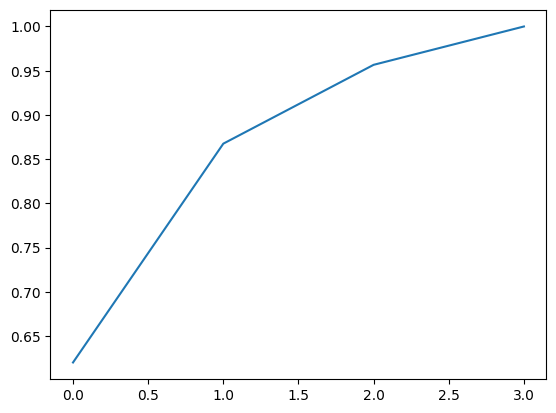

In [13]:
plt.plot(np.cumsum(pca.explained_variance_ratio_));